In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns",None)
sns.set_theme(style="whitegrid")

In [66]:
df=pd.read_csv("../data/college_placement_analytics_5000.csv")
df.head()

,Student_ID,Gender,Graduation_Year,Branch,CGPA,Tenth_Percentage,Twelfth_Percentage,Backlogs,Internship,Projects,Certifications,Skills,DSA_Score,Technical_Score,Aptitude_Score,Communication_Score,Placement_Status,Company,Job_Role,Package_LPA
0,STU20240001,Male,2026,EEE,8.86,89.2,74.7,0,No,3,1,"C, IoT, Embedded C",90.8,93.6,54.3,82.7,Placed,Siemens,Electrical Engineer,6.64
1,STU20240002,Male,2026,IT,9.40,89.0,93.2,0,Yes,5,2,"AWS, SQL, Git, DSA",98.0,81.8,92.1,90.6,Placed,Deloitte,Data Analyst,10.16
2,STU20240003,Female,2024,Mechanical,7.83,NaN,74.8,2,No,2,1,"SolidWorks, CATIA, MATLAB, Excel, Python, C",78.9,82.9,60.4,55.1,Not Placed,Not Placed,Not Placed,0.00
3,STU20240004,Male,2024,EEE,6.61,82.0,69.0,0,No,1,2,"C++, AutoCAD, IoT, SQL, Arduino",67.3,80.1,71.8,97.6,Placed,HCLTech,Electrical Engineer,3.58
4,STU20240005,Male,2025,CSE,9.51,82.2,66.0,1,No,4,1,"Python, Node.js, C++, DSA, Git",78.6,97.6,76.9,65.1,Placed,Infosys,Web Developer,6.45


In [67]:
print("DataSet Shape:",df.shape)
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

DataSet Shape: (5000, 20)
Rows: 5000
Columns: 20


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5000 non-null   str    
 1   Gender               5000 non-null   str    
 2   Graduation_Year      5000 non-null   int64  
 3   Branch               5000 non-null   str    
 4   CGPA                 5000 non-null   float64
 5   Tenth_Percentage     4954 non-null   float64
 6   Twelfth_Percentage   4943 non-null   float64
 7   Backlogs             5000 non-null   int64  
 8   Internship           5000 non-null   str    
 9   Projects             5000 non-null   int64  
 10  Certifications       5000 non-null   int64  
 11  Skills               4933 non-null   str    
 12  DSA_Score            5000 non-null   float64
 13  Technical_Score      5000 non-null   float64
 14  Aptitude_Score       5000 non-null   float64
 15  Communication_Score  5000 non-null   float64
 16 

In [69]:
df.describe()

,Graduation_Year,CGPA,Tenth_Percentage,Twelfth_Percentage,Backlogs,Projects,Certifications,DSA_Score,Technical_Score,Aptitude_Score,Communication_Score,Package_LPA
count,5000.000000,5000.000000,4954.000000,4943.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025.547000,7.819608,77.777150,76.199171,1.033000,2.345000,1.304400,79.373640,82.745600,71.037940,70.407780,4.432514
std,1.076672,0.862264,7.279562,7.455745,1.143929,1.094264,1.186601,12.450585,10.736267,13.189029,12.052913,3.116495
min,2024.000000,5.200000,51.700000,51.800000,0.000000,0.000000,0.000000,33.600000,42.300000,25.000000,35.000000,0.000000
25%,2025.000000,7.230000,72.900000,71.100000,0.000000,2.000000,0.000000,70.800000,75.000000,62.100000,62.175000,0.000000
50%,2026.000000,7.820000,77.700000,76.100000,1.000000,2.000000,1.000000,80.200000,83.300000,71.000000,70.400000,5.590000
75%,2026.000000,8.420000,82.700000,81.200000,2.000000,3.000000,2.000000,88.925000,91.500000,80.100000,78.700000,6.860000
max,2027.000000,9.800000,98.000000,98.000000,6.000000,6.000000,5.000000,98.000000,98.000000,98.000000,98.000000,10.700000


In [70]:
df.columns.tolist()

['Student_ID',
 'Gender',
 'Graduation_Year',
 'Branch',
 'CGPA',
 'Tenth_Percentage',
 'Twelfth_Percentage',
 'Backlogs',
 'Internship',
 'Projects',
 'Certifications',
 'Skills',
 'DSA_Score',
 'Technical_Score',
 'Aptitude_Score',
 'Communication_Score',
 'Placement_Status',
 'Company',
 'Job_Role',
 'Package_LPA']

In [71]:
missing=df.isnull().sum()
missing[missing>0]

Tenth_Percentage      46
Twelfth_Percentage    57
Skills                67
dtype: int64

In [72]:
missing_percentage=(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_percentage[missing_percentage>0]

Skills                1.34
Twelfth_Percentage    1.14
Tenth_Percentage      0.92
dtype: float64

In [74]:
duplicate_count=df.duplicated().sum()
print("Duplicate Rows:",duplicate_count)

Duplicate Rows: 0


In [75]:
df=df.drop_duplicates()
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (5000, 20)


In [76]:
df["Tenth_Percentage"]=df["Tenth_Percentage"].fillna(
    df['Tenth_Percentage'].median()
)
df["Twelfth_Percentage"]=df["Twelfth_Percentage"].fillna(
    df['Twelfth_Percentage'].median()
)

In [77]:
df["Skills"]=df["Skills"].fillna("Unknown")

In [78]:
df.isnull().sum().sum()

np.int64(0)

In [79]:
df["Internship_flag"] = df["Internship"].map({
    "Yes": 1,
    "No": 0
})

df["Placed_flag"] = df["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})


In [80]:
df[["Internship", "Internship_flag", "Placement_Status", "Placed_flag"]].head()

,Internship,Internship_flag,Placement_Status,Placed_flag
0,No,0,Placed,1
1,Yes,1,Placed,1
2,No,0,Not Placed,0
3,No,0,Placed,1
4,No,0,Placed,1


In [81]:
placement_counts=df["Placement_Status"].value_counts()
print(placement_counts)

Placement_Status
Placed        3500
Not Placed    1500
Name: count, dtype: int64


In [82]:
placement_rate=df["Placed_flag"].mean()*100
print(f"overall Placement Rate:{placement_rate:.2f}")

overall Placement Rate:70.00


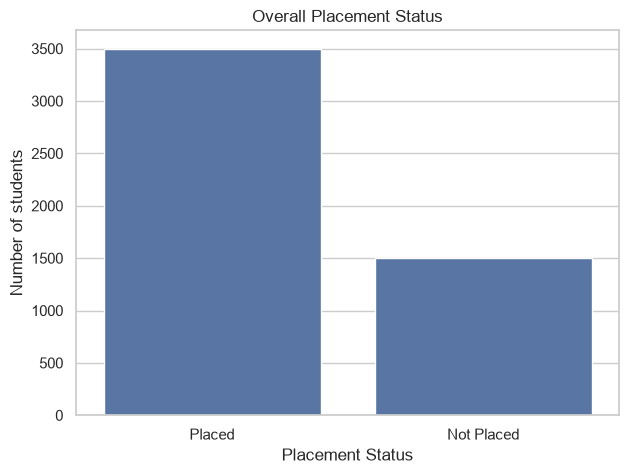

In [83]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Placement_Status"
)
plt.title("Overall Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of students")
plt.show()

In [84]:
branch_placement=(df.groupby("Branch")["Placed_flag"].mean().mul(100).sort_values(ascending=False))
print(branch_placement)

Branch
CSE           89.597781
IT            83.349950
ECE           67.483296
EEE           55.419580
Mechanical    46.114865
Civil         35.699797
Name: Placed_flag, dtype: float64


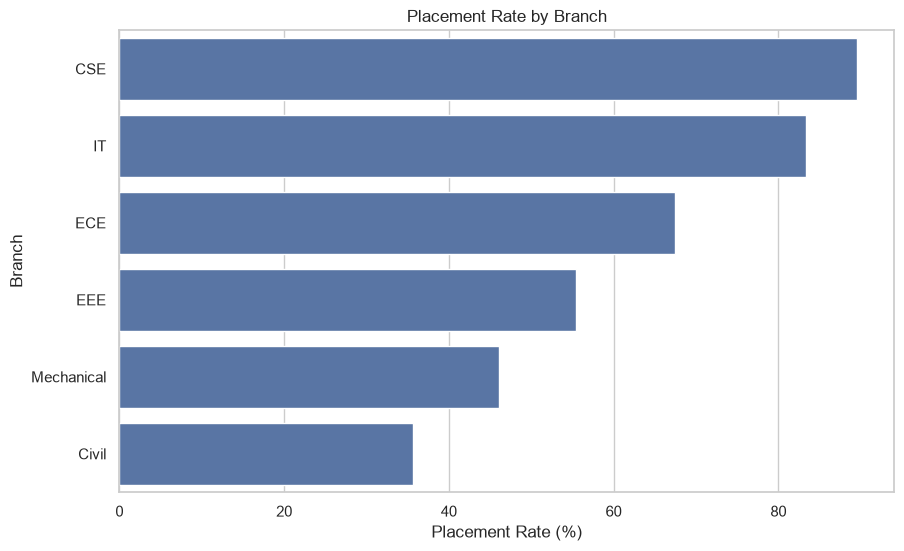

In [85]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=branch_placement.values,
    y=branch_placement.index
)
plt.title("Placement Rate by Branch")
plt.xlabel("Placement Rate (%)")
plt.ylabel("Branch")
plt.show()

In [86]:
year_placement=(df.groupby("Graduation_Year")["Placed_flag"].mean().mul(100))
print(year_placement)

Graduation_Year
2024    71.877891
2025    69.769231
2026    68.776371
2027    70.008354
Name: Placed_flag, dtype: float64


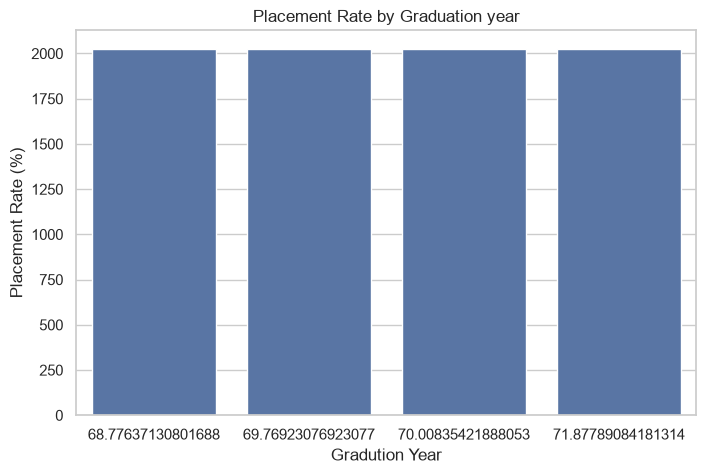

In [87]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=year_placement.values,
    y=year_placement.index
)
plt.title("Placement Rate by Graduation year")
plt.xlabel("Gradution Year")
plt.ylabel("Placement Rate (%)")
plt.show()

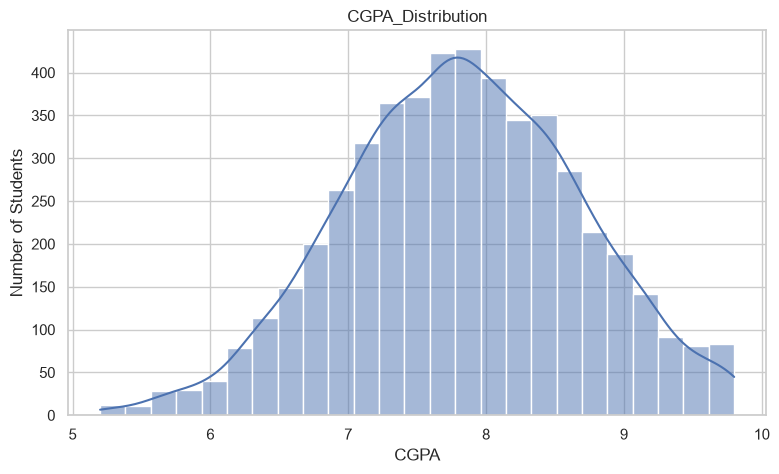

In [88]:
plt.figure(figsize=(9,5))
sns.histplot(
  data=df,
    x="CGPA",
    bins=25,
    kde=True
)
plt.title("CGPA_Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.show()

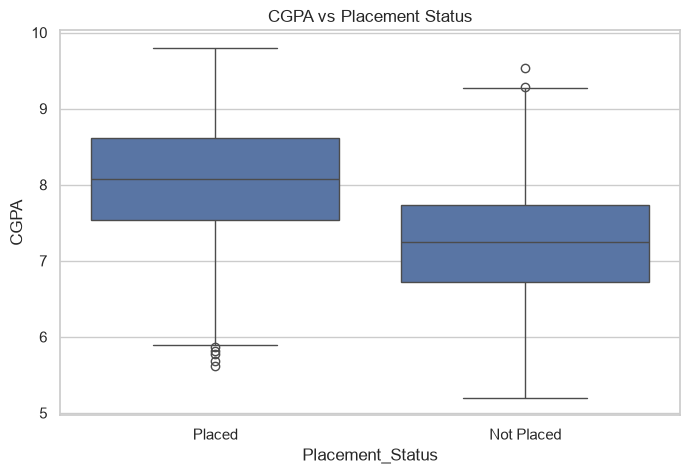

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Placement_Status",
    y="CGPA"
)
plt.title("CGPA vs Placement Status")
plt.show()

In [90]:
acedemic_columns=[
    "Tenth_Percentage",
    "Twelfth_Percentage",
    "CGPA"
]
df[acedemic_columns].describe()

,Tenth_Percentage,Twelfth_Percentage,CGPA
count,5000.000000,5000.000000,5000.000000
mean,77.776440,76.198040,7.819608
std,7.245995,7.413124,0.862264
min,51.700000,51.800000,5.200000
25%,72.900000,71.100000,7.230000
50%,77.700000,76.100000,7.820000
75%,82.700000,81.200000,8.420000
max,98.000000,98.000000,9.800000


In [91]:
df.groupby("Placement_Status")[acedemic_columns].mean()

,Tenth_Percentage,Twelfth_Percentage,CGPA
Placement_Status,,,
Not Placed,75.883800,74.220333,7.221587
Placed,78.587571,77.045629,8.075903


In [92]:
internship_analysis=(
    df.groupby("Internship")["Placed_flag"]
    .agg(
        Total_Students="count",
        Placement_Rate="mean"
    )
)
internship_analysis["Placement_Rate"]*=100
internship_analysis

,Total_Students,Placement_Rate
Internship,,
No,2927,58.524086
Yes,2073,86.203570


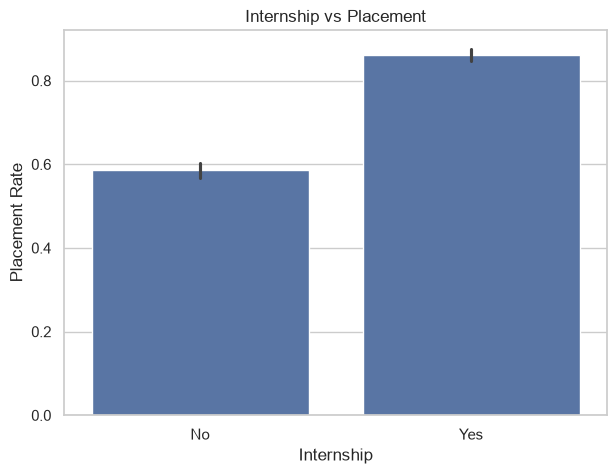

In [93]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Internship",
    y="Placed_flag"
)
plt.title("Internship vs Placement")
plt.ylabel("Placement Rate")
plt.show()

In [94]:
project_analysis = (
    df.groupby("Projects")["Placed_flag"]
    .mean()
    .mul(100)
)

print(project_analysis)

Projects
0     31.000000
1     47.673099
2     67.611336
3     80.802676
4     91.952055
5     93.069307
6    100.000000
Name: Placed_flag, dtype: float64


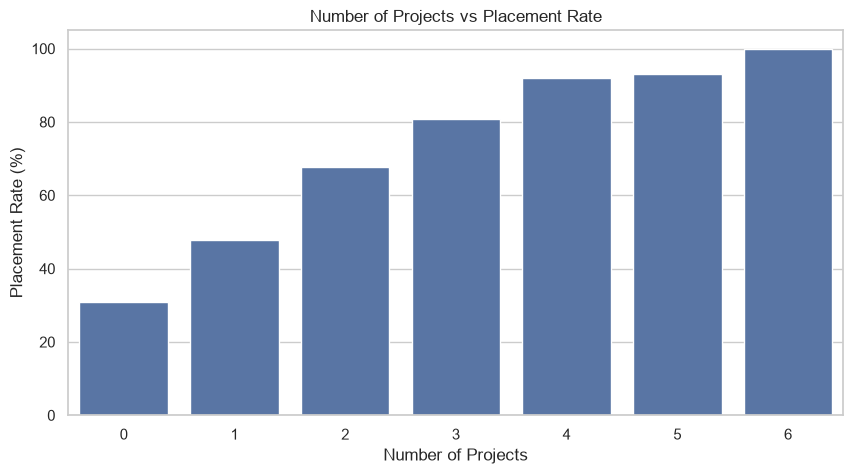

In [95]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=project_analysis.index,
    y=project_analysis.values
)

plt.title("Number of Projects vs Placement Rate")
plt.xlabel("Number of Projects")
plt.ylabel("Placement Rate (%)")

plt.show()

In [96]:
certification_analysis = (
    df.groupby("Certifications")["Placed_flag"]
    .mean()
    .mul(100)
)

print(certification_analysis)

Certifications
0    58.596974
1    68.411660
2    77.119417
3    83.037475
4    84.916201
5    96.341463
Name: Placed_flag, dtype: float64


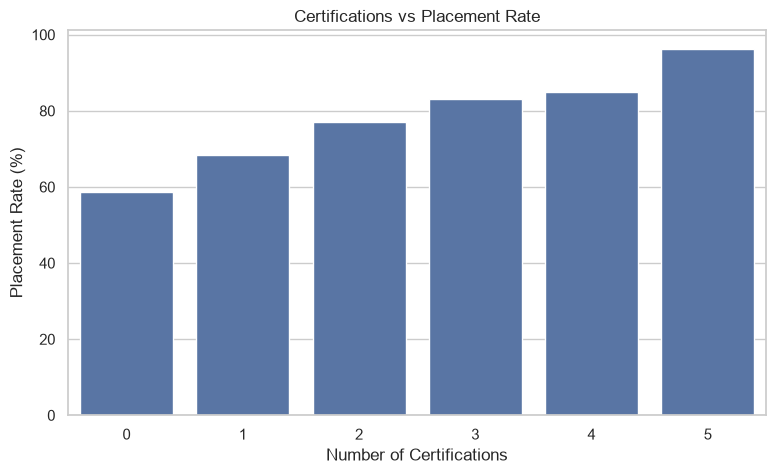

In [97]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=certification_analysis.index,
    y=certification_analysis.values
)

plt.title("Certifications vs Placement Rate")
plt.xlabel("Number of Certifications")
plt.ylabel("Placement Rate (%)")

plt.show()

In [98]:
backlog_analysis = (
    df.groupby("Backlogs")["Placed_flag"]
    .mean()
    .mul(100)
)

print(backlog_analysis)

Backlogs
0    82.943809
1    70.853659
2    56.122449
3    45.092838
4    35.114504
5    30.000000
6    11.764706
Name: Placed_flag, dtype: float64


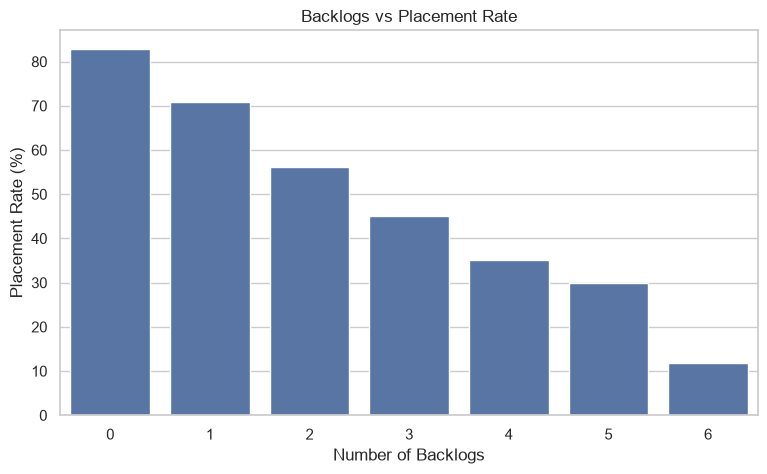

In [99]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=backlog_analysis.index,
    y=backlog_analysis.values
)

plt.title("Backlogs vs Placement Rate")
plt.xlabel("Number of Backlogs")
plt.ylabel("Placement Rate (%)")

plt.show()

In [100]:
skill_series = (
    df["Skills"]
    .dropna()
    .str.split(", ")
    .explode()
)

skill_counts = skill_series.value_counts()

skill_counts.head(20)

Skills
Python        2255
SQL           2237
Java          1727
C++           1545
Git           1474
C             1165
MongoDB       1120
DSA           1118
JavaScript    1106
MATLAB        1092
Node.js       1072
React         1056
AutoCAD        745
Arduino        667
Embedded C     655
IoT            634
Excel          484
AWS            432
SolidWorks     270
CATIA          258
Name: count, dtype: int64

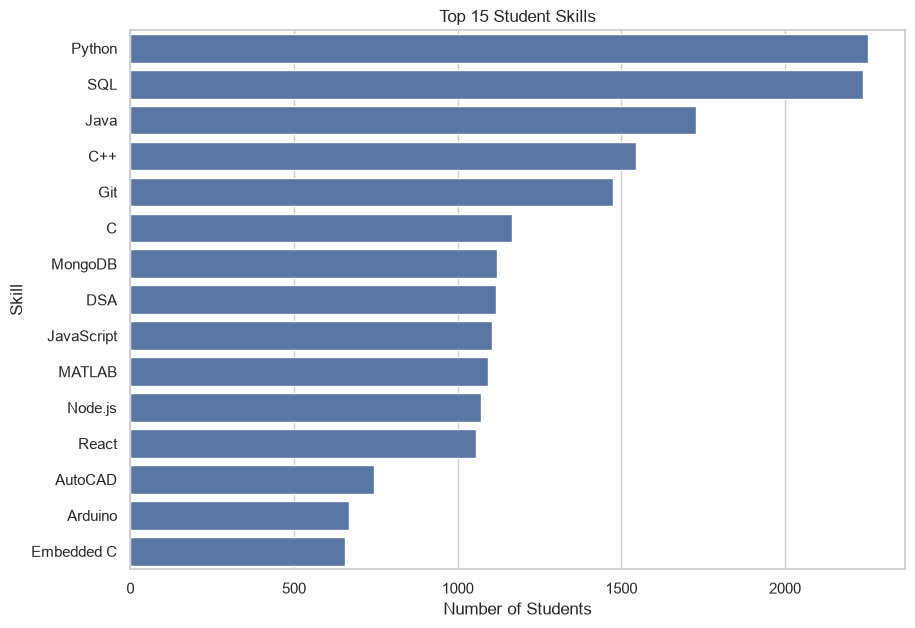

In [101]:
top_skills = skill_counts.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title("Top 15 Student Skills")
plt.xlabel("Number of Students")
plt.ylabel("Skill")

plt.show()

In [102]:
placed_df = df[
    df["Placement_Status"] == "Placed"
].copy()

placed_skills = (
    placed_df["Skills"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

placed_skills.head(15)

Skills
SQL           1586
Python        1583
Java          1353
Git           1199
C++           1121
MongoDB        982
DSA            972
JavaScript     959
Node.js        925
React          897
C              610
MATLAB         586
Arduino        409
IoT            407
Embedded C     407
Name: count, dtype: int64

In [103]:
placed_df = df[
    df["Package_LPA"] > 0
].copy()

In [104]:
average_package = placed_df["Package_LPA"].mean()

print(f"Average Package: ₹{average_package:.2f} LPA")

Average Package: ₹6.33 LPA


In [105]:
highest_package = placed_df["Package_LPA"].max()

print(f"Highest Package: ₹{highest_package:.2f} LPA")

Highest Package: ₹10.70 LPA


In [106]:
median_package = placed_df["Package_LPA"].median()

print(f"Median Package: ₹{median_package:.2f} LPA")

Median Package: ₹6.35 LPA


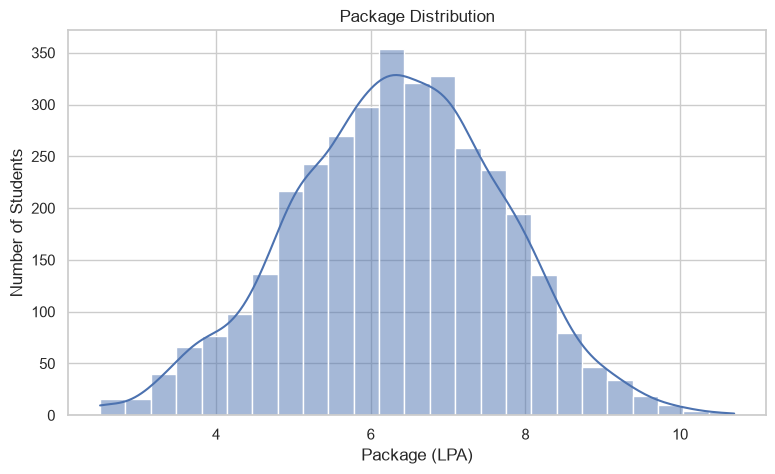

In [107]:
plt.figure(figsize=(9, 5))

sns.histplot(
    placed_df["Package_LPA"],
    bins=25,
    kde=True
)

plt.title("Package Distribution")
plt.xlabel("Package (LPA)")
plt.ylabel("Number of Students")

plt.show()

In [108]:
branch_package = (
    placed_df
    .groupby("Branch")["Package_LPA"]
    .mean()
    .sort_values(ascending=False)
)

print(branch_package)

Branch
CSE           6.867245
IT            6.562548
ECE           5.866139
EEE           5.848833
Mechanical    5.339194
Civil         5.325227
Name: Package_LPA, dtype: float64


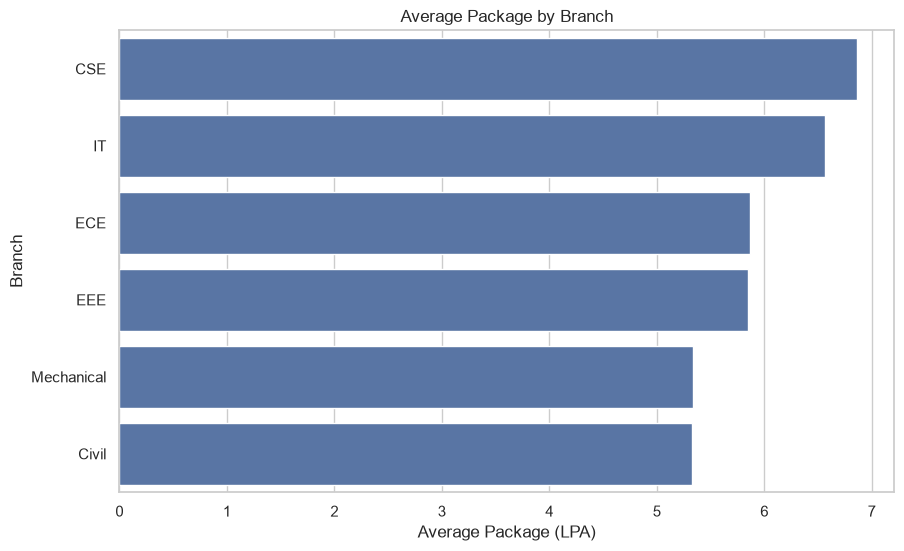

In [109]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=branch_package.values,
    y=branch_package.index
)

plt.title("Average Package by Branch")
plt.xlabel("Average Package (LPA)")
plt.ylabel("Branch")

plt.show()

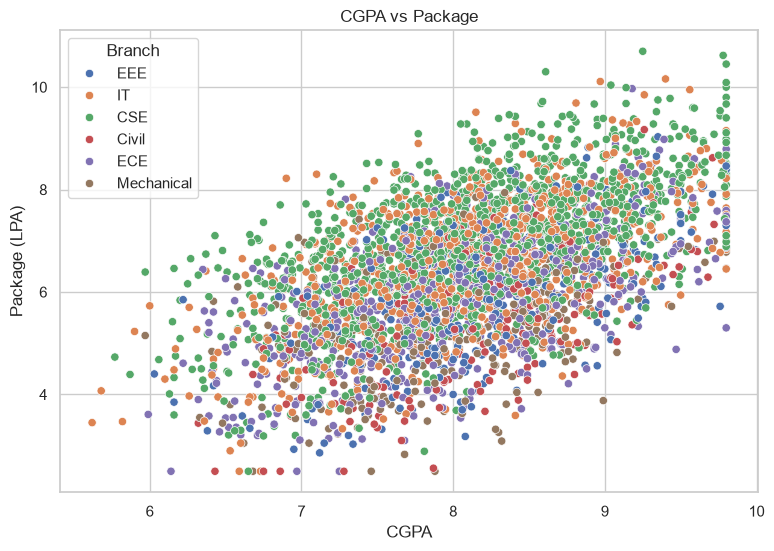

In [110]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=placed_df,
    x="CGPA",
    y="Package_LPA",
    hue="Branch"
)

plt.title("CGPA vs Package")
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")

plt.show()

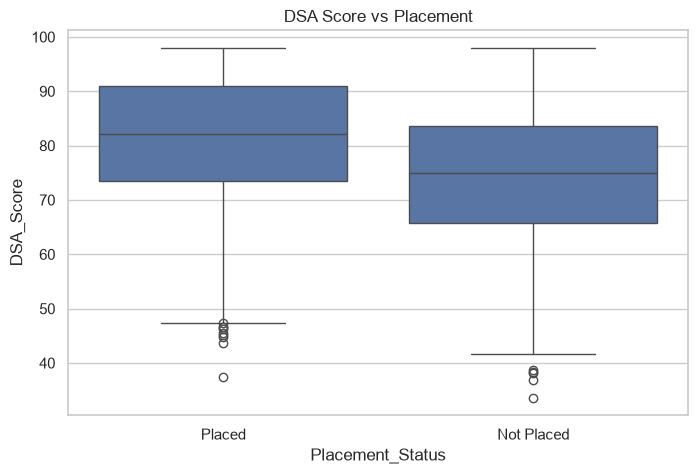

In [111]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Placement_Status",
    y="DSA_Score"
)

plt.title("DSA Score vs Placement")

plt.show()

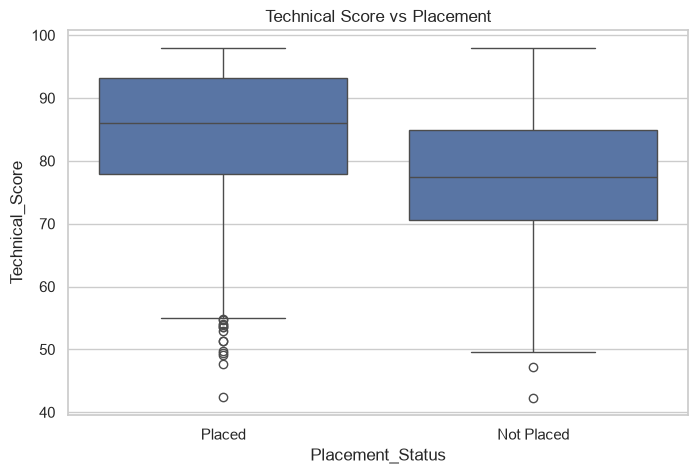

In [112]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Placement_Status",
    y="Technical_Score"
)

plt.title("Technical Score vs Placement")

plt.show()

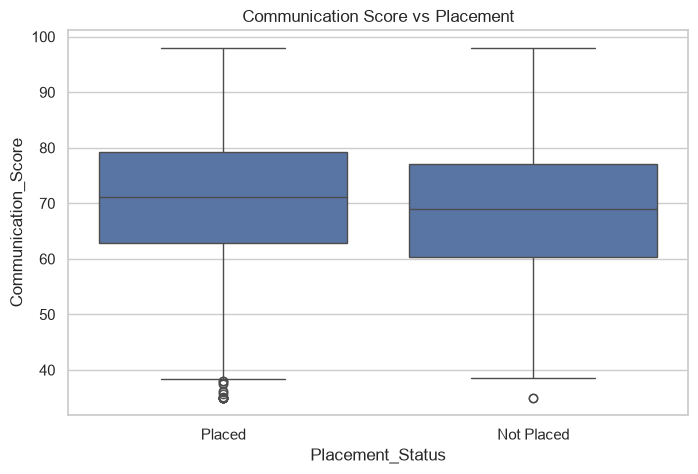

In [113]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Placement_Status",
    y="Communication_Score"
)

plt.title("Communication Score vs Placement")

plt.show()

In [114]:
numeric_columns = [
    "CGPA",
    "Tenth_Percentage",
    "Twelfth_Percentage",
    "Backlogs",
    "Projects",
    "Certifications",
    "DSA_Score",
    "Technical_Score",
    "Aptitude_Score",
    "Communication_Score",
    "Placed_flag",
    "Package_LPA"
]

correlation = df[numeric_columns].corr()

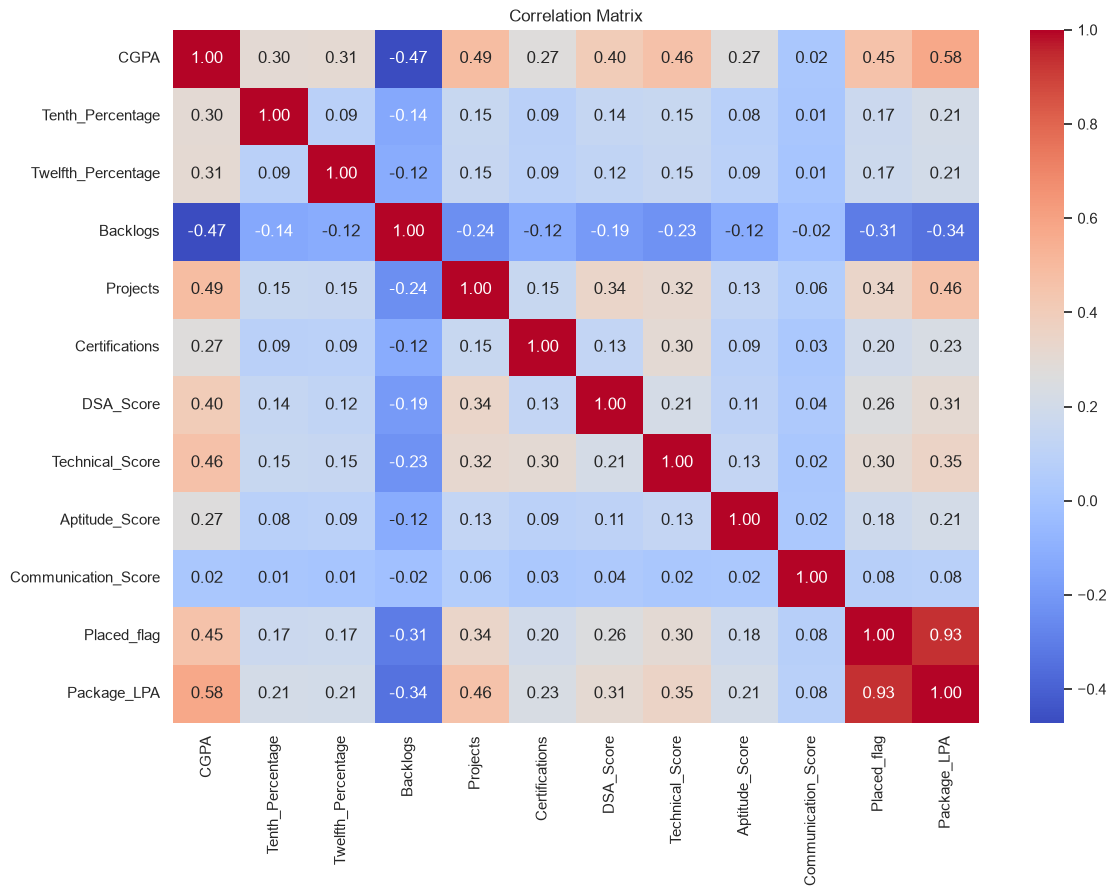

In [115]:
plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [116]:
import os
import sqlite3

# Create data folder if it doesn't exist
os.makedirs("../data", exist_ok=True)

# Connect to SQLite database
connection = sqlite3.connect("../data/campuspulse.db")

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [118]:
df.to_sql(
    "students",
    connection,
    if_exists="replace",
    index=False
)

5000

In [119]:
query = """
SELECT COUNT(*) AS total_students
FROM students;
"""

pd.read_sql_query(query, connection)

,total_students
0,5000


In [120]:
query = """
SELECT
    Placement_Status,
    COUNT(*) AS student_count
FROM students
GROUP BY Placement_Status;
"""

pd.read_sql_query(query, connection)

,Placement_Status,student_count
0,Not Placed,1500
1,Placed,3500


In [121]:
query = """
SELECT
    Branch,
    COUNT(*) AS total_students,
    SUM(Placed_Flag) AS placed_students,
    ROUND(AVG(Placed_Flag) * 100, 2) AS placement_rate
FROM students
GROUP BY Branch
ORDER BY placement_rate DESC;
"""

pd.read_sql_query(query, connection)

,Branch,total_students,placed_students,placement_rate
0,CSE,1442,1292,89.60
1,IT,1003,836,83.35
2,ECE,898,606,67.48
3,EEE,572,317,55.42
4,Mechanical,592,273,46.11
5,Civil,493,176,35.70


In [122]:
query = """
SELECT
    Branch,
    ROUND(
        AVG(
            CASE
                WHEN Package_LPA > 0
                THEN Package_LPA
            END
        ),
        2
    ) AS average_package
FROM students
GROUP BY Branch
ORDER BY average_package DESC;
"""

pd.read_sql_query(query, connection)

,Branch,average_package
0,CSE,6.87
1,IT,6.56
2,ECE,5.87
3,EEE,5.85
4,Mechanical,5.34
5,Civil,5.33


In [123]:
query = """
SELECT
    Internship,
    COUNT(*) AS total_students,
    SUM(Placed_Flag) AS placed_students,
    ROUND(AVG(Placed_Flag) * 100, 2) AS placement_rate
FROM students
GROUP BY Internship;
"""

pd.read_sql_query(query, connection)

,Internship,total_students,placed_students,placement_rate
0,No,2927,1713,58.52
1,Yes,2073,1787,86.20


In [124]:
query = """
SELECT
    Company,
    COUNT(*) AS students_hired
FROM students
WHERE Placement_Status = 'Placed'
GROUP BY Company
ORDER BY students_hired DESC;
"""

pd.read_sql_query(query, connection)

,Company,students_hired
0,Wipro,378
1,TCS,366
2,Infosys,313
3,Deloitte,260
4,Cognizant,253
5,Capgemini,242
6,Zoho,233
7,HCLTech,221
8,Tech Mahindra,218
9,Accenture,213


In [125]:
query = """
SELECT
    Job_Role,
    COUNT(*) AS students_hired
FROM students
WHERE Placement_Status = 'Placed'
GROUP BY Job_Role
ORDER BY students_hired DESC;
"""

pd.read_sql_query(query, connection)

,Job_Role,students_hired
0,Software Developer,643
1,QA Engineer,579
2,Data Analyst,454
3,Backend Developer,272
4,Embedded Engineer,260
5,Web Developer,242
6,Graduate Engineer Trainee,189
7,Full Stack Developer,160
8,Support Engineer,154
9,Network Engineer,140


In [127]:
features = [
    "CGPA",
    "Tenth_Percentage",
    "Twelfth_Percentage",
    "Backlogs",
    "Internship_flag",
    "Projects",
    "Certifications",
    "DSA_Score",
    "Technical_Score",
    "Aptitude_Score",
    "Communication_Score"
]

X = df[features]
y = df["Placed_flag"]

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 4000
Testing records: 1000


In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['CGPA','Tenth_Percentage','Twelfth_Percentage',...,'Technical_Score', 'Aptitude_Score','Communication_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [130]:
logistic_pred = logistic_model.predict(X_test)

In [131]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        logistic_pred
    )
)

print(
    classification_report(
        y_test,
        logistic_pred
    )
)

Logistic Regression Accuracy: 0.799
              precision    recall  f1-score   support

           0       0.72      0.54      0.62       300
           1       0.82      0.91      0.86       700

    accuracy                           0.80      1000
   macro avg       0.77      0.73      0.74      1000
weighted avg       0.79      0.80      0.79      1000



In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [133]:
rf_pred = rf_model.predict(X_test)

In [134]:
print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.797
              precision    recall  f1-score   support

           0       0.72      0.53      0.61       300
           1       0.82      0.91      0.86       700

    accuracy                           0.80      1000
   macro avg       0.77      0.72      0.74      1000
weighted avg       0.79      0.80      0.79      1000



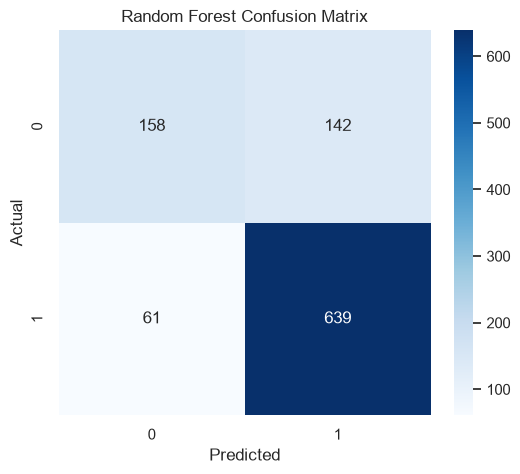

In [135]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [136]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            logistic_pred
        ),
        accuracy_score(
            y_test,
            rf_pred
        )
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.799
1,Random Forest,0.797


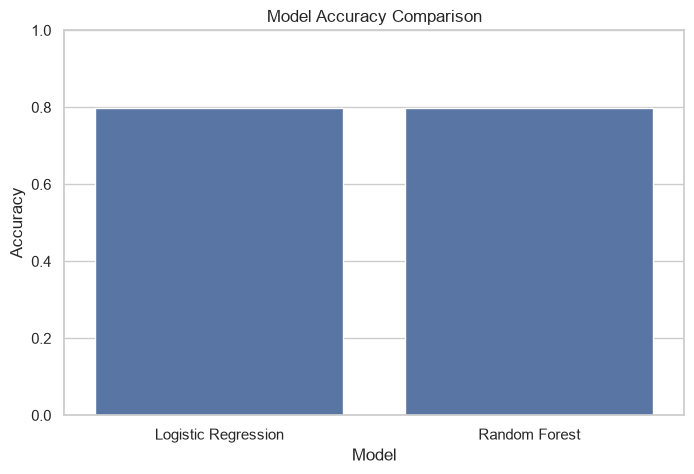

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

In [138]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

feature_importance

CGPA                   0.229856
Technical_Score        0.110505
DSA_Score              0.094978
Projects               0.082107
Internship_flag        0.082017
Aptitude_Score         0.081579
Twelfth_Percentage     0.080532
Tenth_Percentage       0.078189
Communication_Score    0.075652
Backlogs               0.056492
Certifications         0.028093
dtype: float64

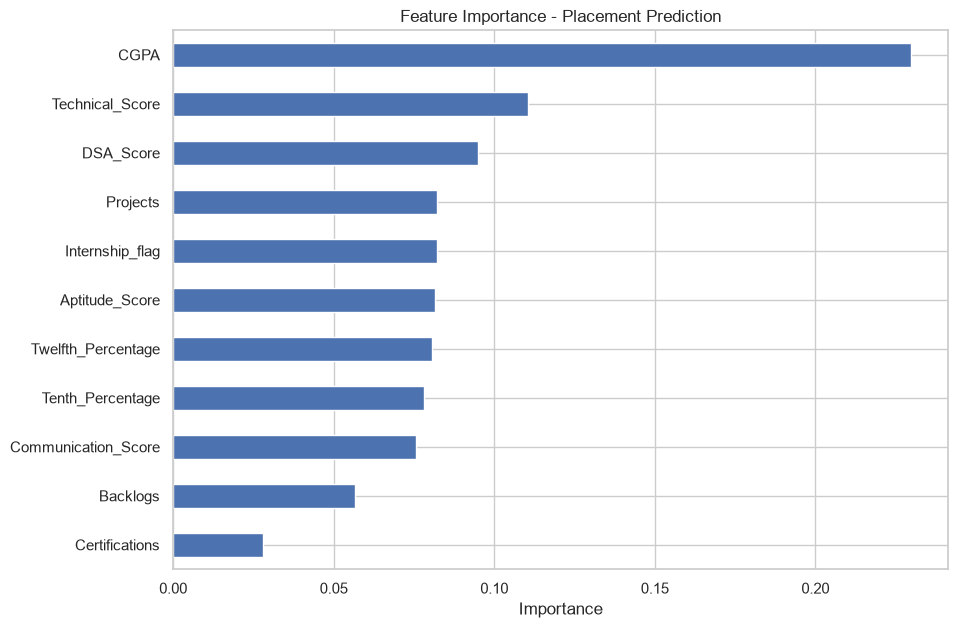

In [139]:
plt.figure(figsize=(10, 7))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Importance - Placement Prediction"
)

plt.xlabel("Importance")

plt.show()

In [141]:
student = pd.DataFrame([{
    "CGPA": 8.5,
    "Tenth_Percentage": 85,
    "Twelfth_Percentage": 82,
    "Backlogs": 0,
    "Internship_flag": 1,
    "Projects": 3,
    "Certifications": 2,
    "DSA_Score": 80,
    "Technical_Score": 82,
    "Aptitude_Score": 75,
    "Communication_Score": 78
}])

prediction = rf_model.predict(student)[0]

probability = rf_model.predict_proba(student)[0][1]

print(
    "Prediction:",
    "Placed" if prediction == 1 else "Not Placed"
)

print(
    f"Model probability: {probability * 100:.2f}%"
)

Prediction: Placed
Model probability: 98.73%


In [142]:
salary_df = df[
    df["Placement_Status"] == "Placed"
].copy()

print(
    "Placed students:",
    len(salary_df)
)

Placed students: 3500


In [145]:
salary_features = [
    "CGPA",
    "Tenth_Percentage",
    "Twelfth_Percentage",
    "Backlogs",
    "Internship_flag",
    "Projects",
    "Certifications",
    "DSA_Score",
    "Technical_Score",
    "Aptitude_Score",
    "Communication_Score"
]

X_salary = salary_df[salary_features]

y_salary = salary_df["Package_LPA"]

In [146]:
X_train_salary, X_test_salary, y_train_salary, y_test_salary = train_test_split(
    X_salary,
    y_salary,
    test_size=0.20,
    random_state=42
)

In [147]:
from sklearn.ensemble import RandomForestRegressor

salary_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

salary_model.fit(
    X_train_salary,
    y_train_salary
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [148]:
salary_pred = salary_model.predict(
    X_test_salary
)

In [149]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_salary,
    salary_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_salary,
        salary_pred
    )
)

r2 = r2_score(
    y_test_salary,
    salary_pred
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

MAE: 0.83
RMSE: 1.04
R²: 0.374


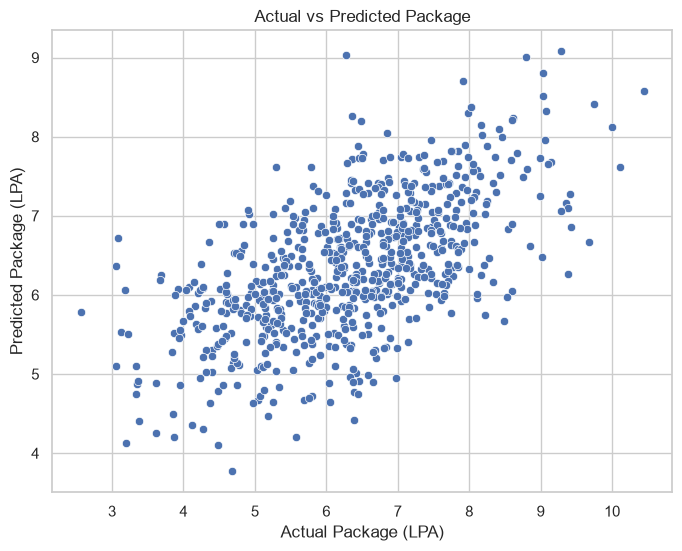

In [150]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_salary,
    y=salary_pred
)

plt.xlabel("Actual Package (LPA)")
plt.ylabel("Predicted Package (LPA)")
plt.title("Actual vs Predicted Package")

plt.show()

In [155]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model,
    "../models/placement_model.pkl"
)

joblib.dump(
    salary_model,
    "../models/salary_model.pkl"
)

print("Models saved successfully.")

Models saved successfully.
